<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Deep-Neural-Network/blob/master/Exam/task2_2324.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Neural networks are known to "trick" us by exploiting unobvious shortcuts to achieve good performance (e.g., when tasked with recognizing if a wolf or a dog is on the image, they could learn to recognize the features of terrain instead).  Convolutional Neural Networks (CNN) are extremely useful in image classification tasks. They recognize patterns in the data by encoding various features in the images such as edges, lines, circles.
We hope a neural network to depend solely on pixels it sees, but... position information might be useful as well.

Can a CNN recover information about the position of each pixel just from pixel values and padding? In this task, you will verify this hypothesis.

You have to implement a CNN model which will predict the position of each pixel (the x or y coordinate normalized to [0,1]) using convolutional layers.



The ideal model would output something like this: 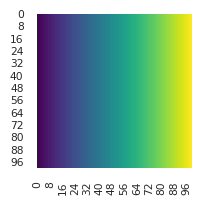

In [1]:
import torch.nn.functional as F
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn
from torch import optim
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


# Implement SimpleConvnet (5p)
This model consist of two parts:
- a parametrized number of blocks
- linear projection

Each block should have two layers: *convolution* and *relu*. The number of blocks is parametrized by the **n_convolutions** argument. All convolutions layers **in blocks** should have a kernel_size equal to 3 and padding equal to 1.

The input to the model has the shape: (batch_size, 1, spatial_dimension, spatial_dimension), so it starts with only 1 channel (filter). First 4 blocks should double the number of channels. Blocks from index 4 upward should keep the number of channels (filters) unchanged.

Linear projection should decrease the number of channels to 1. Therefore, the output of the model should match the input in shape.

In [27]:
class SimpleConvnet(nn.Module):
    def __init__(self, n_convolutions):
        super(SimpleConvnet, self).__init__()
        # TODO
        modules = []
        in_channels = 1
        for i in range(n_convolutions):
          if i<4:
            out_channels = in_channels * 2
          else:
            out_channels = in_channels
          modules.append(nn.Conv2d(in_channels, out_channels, 3, padding=1))
          modules.append(nn.ReLU())
          in_channels = out_channels
        modules.append(nn.Conv2d(in_channels, 1, 3,  padding=1))

        self.layers = nn.Sequential(*modules)
        # END TODO


    def forward(self, x):
      # TODO
      x = self.layers(x)
      return x

      # END TODO


## Helper functions

In [3]:
def visualize(array):
  plt.figure(figsize=(2,2))
  sns.set(font_scale=0.7)
  sns.heatmap(array, cmap='viridis', cbar=False, annot=False)
  plt.show()

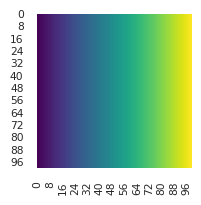

In [4]:
def generate_spectrum(spatial_dimension):
  row = torch.linspace(0, 1, spatial_dimension)
  return row.expand(spatial_dimension, -1)
spectrum = generate_spectrum(100)
visualize(spectrum.numpy())

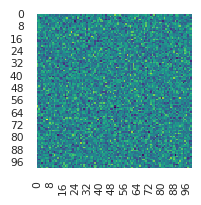

In [5]:
def generate_noise(batch_size, spatial_dimension):
  return torch.randn(batch_size, 1, spatial_dimension, spatial_dimension)
visualize(generate_noise(1,100)[0].squeeze().numpy())

## Training (1p)
Implement target preparation.

In [28]:

def train(epochs, steps, batch_size, model, optimizer, spatial_dimension, verbose=1):
    model.train()

    # TODO
    # Prepare target (it will be the same in every sample)
    spectrum = generate_spectrum(spatial_dimension)
    target = []
    for i in range(batch_size):
      target.append(spectrum)
    target = torch.stack(target)
    target = target.reshape(batch_size, 1, spatial_dimension, spatial_dimension)

    # ENDTODO
    assert target.shape == torch.Size([batch_size, 1, spatial_dimension, spatial_dimension])

    for epoch in range(epochs):
        running_loss = 0
        for i in range(steps):
            noise = generate_noise(batch_size, spatial_dimension)
            predicted = model(noise)
            loss = F.mse_loss(predicted, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        if verbose > 0:
          print('Epoch [{}/{}], Loss: {:.4f}'
                  .format(epoch + 1, epochs, running_loss / steps))
          with torch.no_grad():
            input = generate_noise(1, spatial_dimension)
            predicted_gradient = model(input)[0].numpy()
            visualize(predicted_gradient.squeeze(0))

Epoch [1/20], Loss: 0.1239


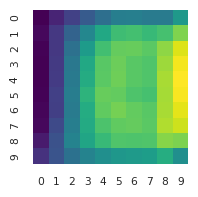

Epoch [2/20], Loss: 0.0146


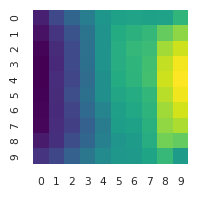

Epoch [3/20], Loss: 0.0051


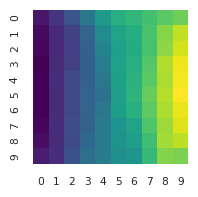

Epoch [4/20], Loss: 0.0019


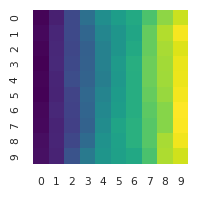

Epoch [5/20], Loss: 0.0011


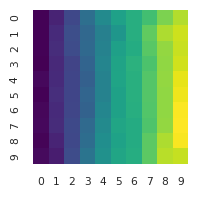

Epoch [6/20], Loss: 0.0008


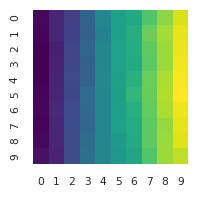

Epoch [7/20], Loss: 0.0006


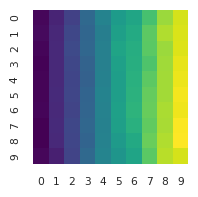

Epoch [8/20], Loss: 0.0005


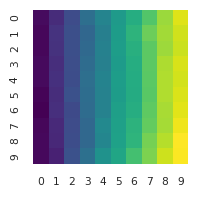

Epoch [9/20], Loss: 0.0004


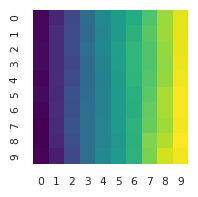

Epoch [10/20], Loss: 0.0003


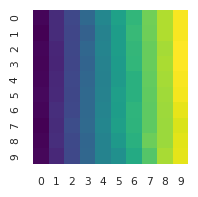

Epoch [11/20], Loss: 0.0003


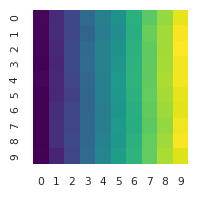

Epoch [12/20], Loss: 0.0002


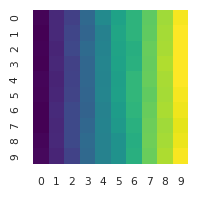

Epoch [13/20], Loss: 0.0002


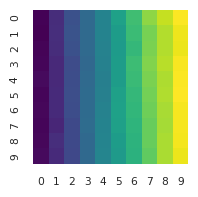

Epoch [14/20], Loss: 0.0002


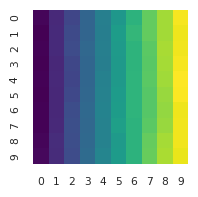

Epoch [15/20], Loss: 0.0001


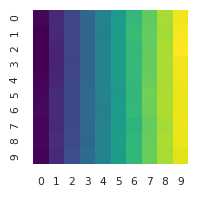

Epoch [16/20], Loss: 0.0001


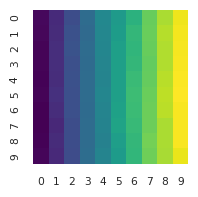

Epoch [17/20], Loss: 0.0001


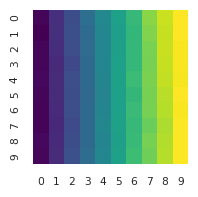

Epoch [18/20], Loss: 0.0001


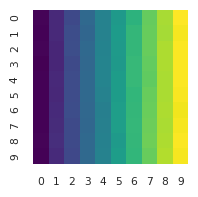

Epoch [19/20], Loss: 0.0001


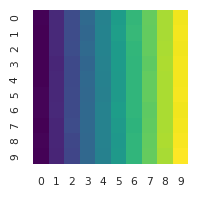

Epoch [20/20], Loss: 0.0001


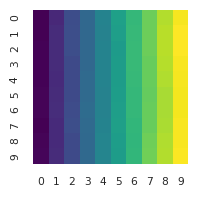

In [29]:
# Check if training works
# do not exceed n_convolutions = 10 and spatial_dimension = 20
n_convolutions = 5 #  TODO
spatial_dimension = 10 # TODO
epochs = 20
steps = 50

model = SimpleConvnet(n_convolutions)
optimizer = optim.Adam(model.parameters(), lr=0.001)

train(epochs=epochs, steps=steps, batch_size=256, model=model, optimizer=optimizer, spatial_dimension=spatial_dimension, verbose=1)

## Experiments (5p)

Create two lists:
- *n_convolutions_params* with 4 different values (suggested [2, 4, 6, 8])
- *spatial_dimensions_params* with 4 different values (suggested [5,10,15,20])

For each pair (n_convolutions,spatial_dimensions) $\in$ (n_convolutions_params $\times$ spatial_dimensions_param), train a model with these parameters and visualize the prediction of the trained model on a sampled noise.

Represent these vizualizations on image grid of shape 4 $\times$ 4. Explain these results.

(Note: do not exceed n_convolutions = 10 and spatial_dimension = 20. It takes about 2min on CPU to train model with these parameters. )

(Note2: *visualize* function runs plt.show() so it can interfere with image grid. You can disable it by changing verbose argument in *train* to 0.)


Epoch [1/20], Loss: 0.4546


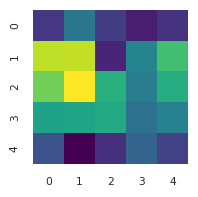

Epoch [2/20], Loss: 0.2202


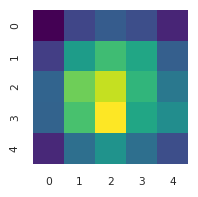

Epoch [3/20], Loss: 0.1064


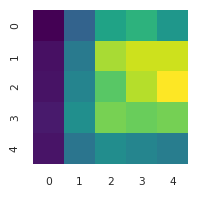

Epoch [4/20], Loss: 0.0622


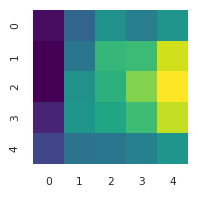

Epoch [5/20], Loss: 0.0416


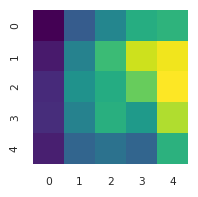

Epoch [6/20], Loss: 0.0337


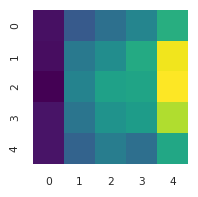

Epoch [7/20], Loss: 0.0298


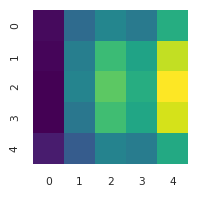

Epoch [8/20], Loss: 0.0268


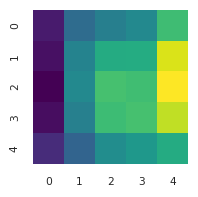

Epoch [9/20], Loss: 0.0241


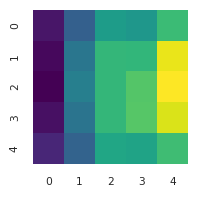

Epoch [10/20], Loss: 0.0216


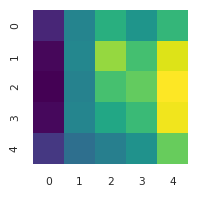

Epoch [11/20], Loss: 0.0195


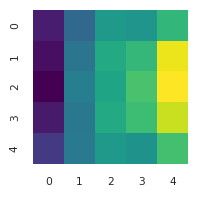

Epoch [12/20], Loss: 0.0176


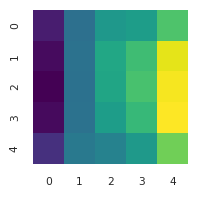

Epoch [13/20], Loss: 0.0158


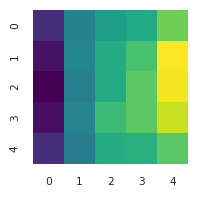

Epoch [14/20], Loss: 0.0141


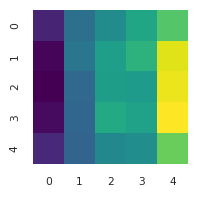

Epoch [15/20], Loss: 0.0126


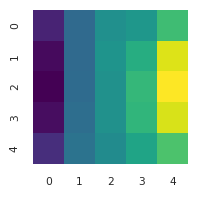

Epoch [16/20], Loss: 0.0112


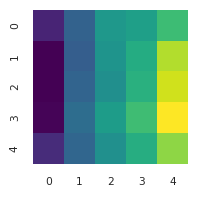

Epoch [17/20], Loss: 0.0100


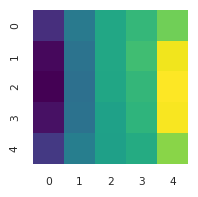

Epoch [18/20], Loss: 0.0089


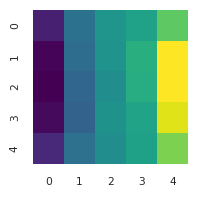

Epoch [19/20], Loss: 0.0079


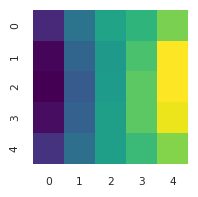

Epoch [20/20], Loss: 0.0070


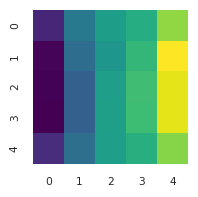

Epoch [1/20], Loss: 0.2032


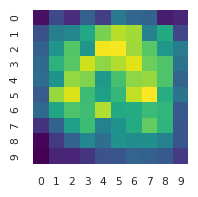

Epoch [2/20], Loss: 0.1034


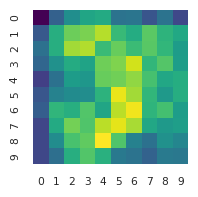

Epoch [3/20], Loss: 0.0719


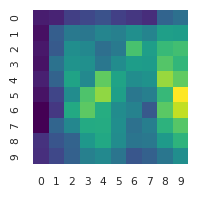

Epoch [4/20], Loss: 0.0466


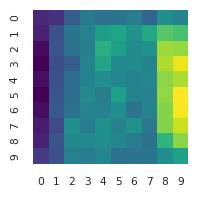

Epoch [5/20], Loss: 0.0369


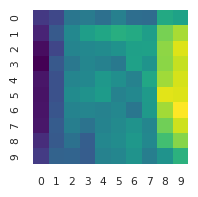

Epoch [6/20], Loss: 0.0330


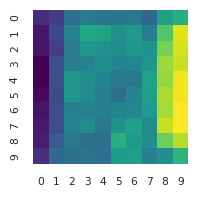

Epoch [7/20], Loss: 0.0305


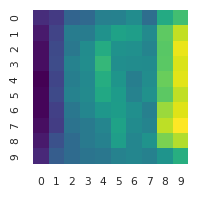

Epoch [8/20], Loss: 0.0287


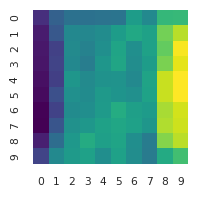

Epoch [9/20], Loss: 0.0274


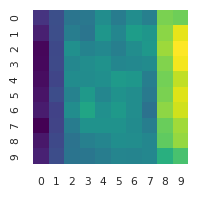

Epoch [10/20], Loss: 0.0263


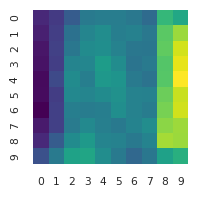

Epoch [11/20], Loss: 0.0254


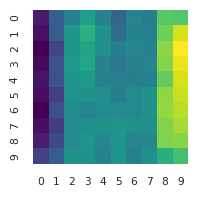

Epoch [12/20], Loss: 0.0247


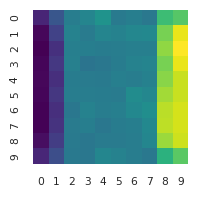

Epoch [13/20], Loss: 0.0240


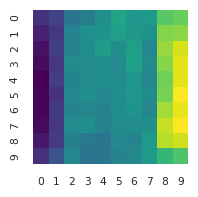

Epoch [14/20], Loss: 0.0235


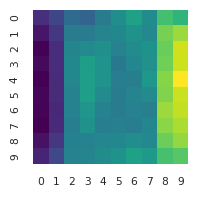

Epoch [15/20], Loss: 0.0230


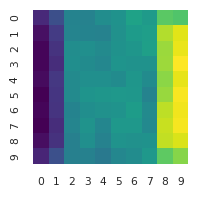

Epoch [16/20], Loss: 0.0225


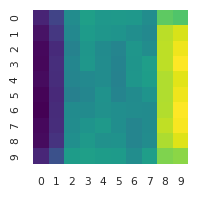

Epoch [17/20], Loss: 0.0220


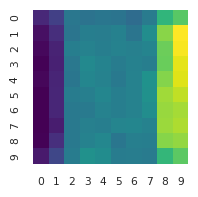

Epoch [18/20], Loss: 0.0216


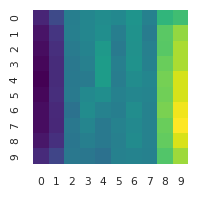

Epoch [19/20], Loss: 0.0211


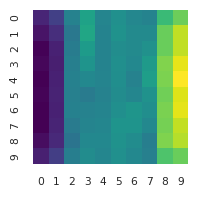

Epoch [20/20], Loss: 0.0206


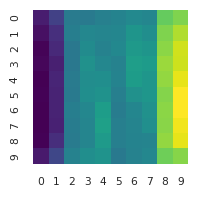

Epoch [1/20], Loss: 0.1204


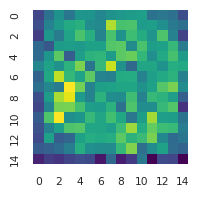

Epoch [2/20], Loss: 0.0916


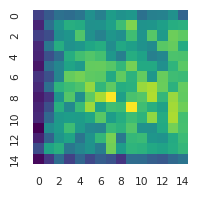

Epoch [3/20], Loss: 0.0657


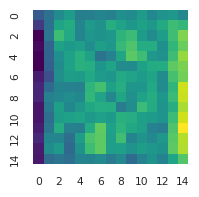

Epoch [4/20], Loss: 0.0525


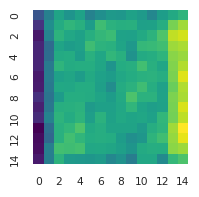

Epoch [5/20], Loss: 0.0474


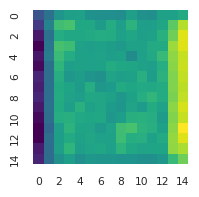

Epoch [6/20], Loss: 0.0444


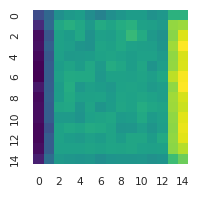

Epoch [7/20], Loss: 0.0423


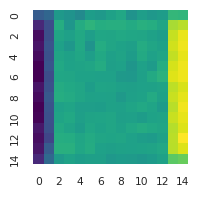

Epoch [8/20], Loss: 0.0410


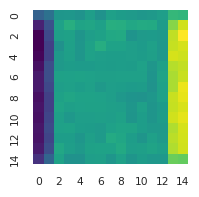

Epoch [9/20], Loss: 0.0401


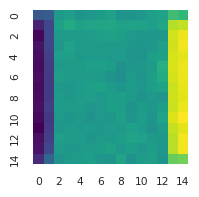

Epoch [10/20], Loss: 0.0395


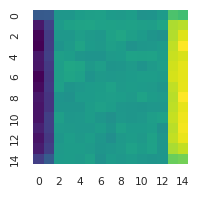

Epoch [11/20], Loss: 0.0391


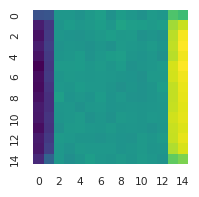

Epoch [12/20], Loss: 0.0389


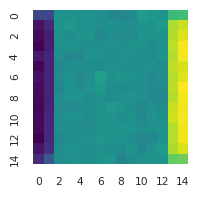

Epoch [13/20], Loss: 0.0387


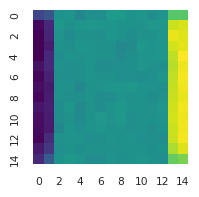

Epoch [14/20], Loss: 0.0386


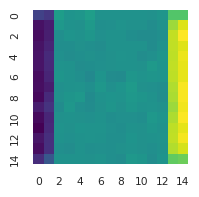

Epoch [15/20], Loss: 0.0385


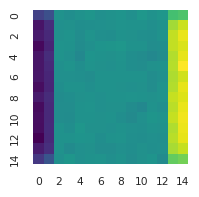

Epoch [16/20], Loss: 0.0384


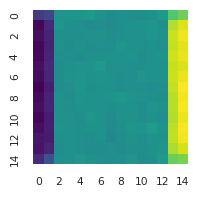

Epoch [17/20], Loss: 0.0384


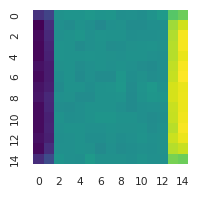

Epoch [18/20], Loss: 0.0383


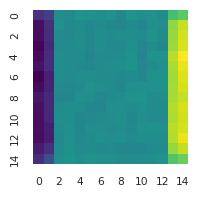

Epoch [19/20], Loss: 0.0382


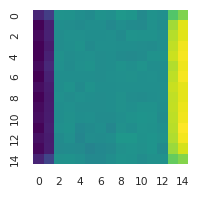

Epoch [20/20], Loss: 0.0381


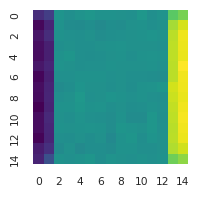

Epoch [1/20], Loss: 0.1601


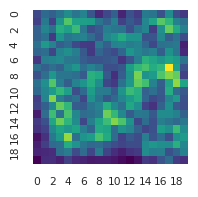

Epoch [2/20], Loss: 0.1036


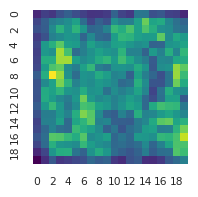

Epoch [3/20], Loss: 0.0938


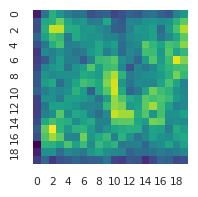

Epoch [4/20], Loss: 0.0852


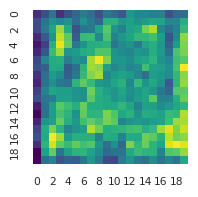

Epoch [5/20], Loss: 0.0761


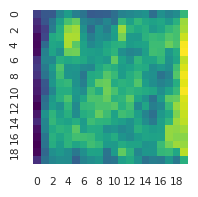

Epoch [6/20], Loss: 0.0689


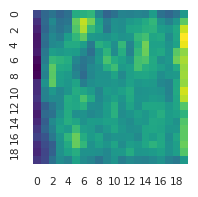

Epoch [7/20], Loss: 0.0644


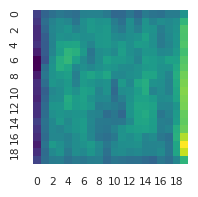

Epoch [8/20], Loss: 0.0614


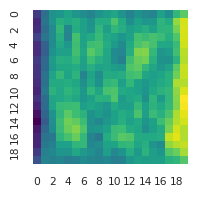

Epoch [9/20], Loss: 0.0591


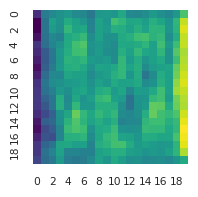

Epoch [10/20], Loss: 0.0574


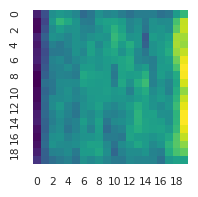

Epoch [11/20], Loss: 0.0557


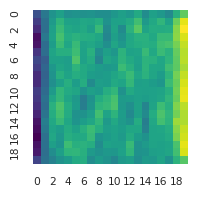

Epoch [12/20], Loss: 0.0543


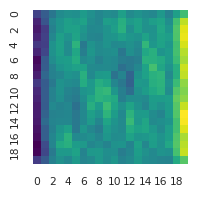

Epoch [13/20], Loss: 0.0530


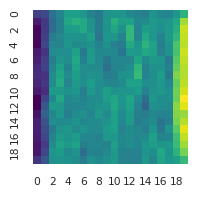

Epoch [14/20], Loss: 0.0518


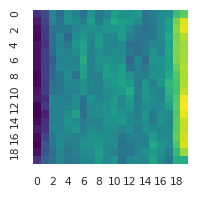

Epoch [15/20], Loss: 0.0506


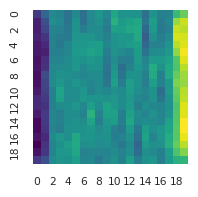

Epoch [16/20], Loss: 0.0493


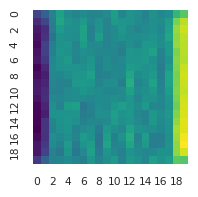

Epoch [17/20], Loss: 0.0485


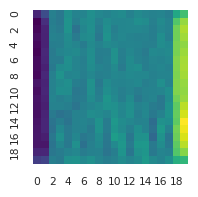

Epoch [18/20], Loss: 0.0480


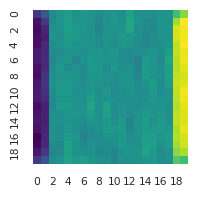

Epoch [19/20], Loss: 0.0478


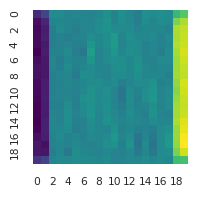

Epoch [20/20], Loss: 0.0477


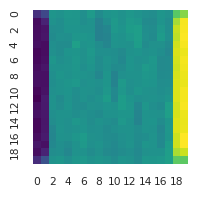

Epoch [1/20], Loss: 0.1382


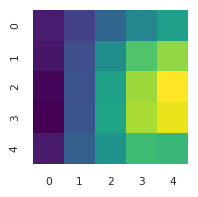

Epoch [2/20], Loss: 0.0158


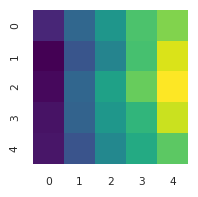

Epoch [3/20], Loss: 0.0038


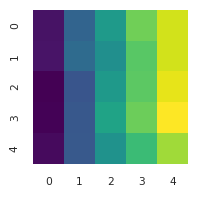

Epoch [4/20], Loss: 0.0017


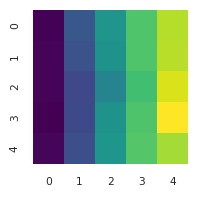

Epoch [5/20], Loss: 0.0011


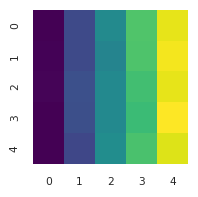

Epoch [6/20], Loss: 0.0007


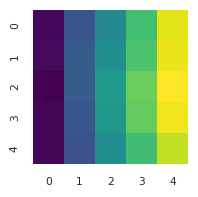

Epoch [7/20], Loss: 0.0006


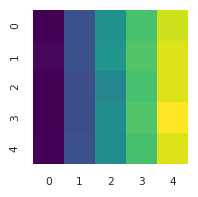

Epoch [8/20], Loss: 0.0005


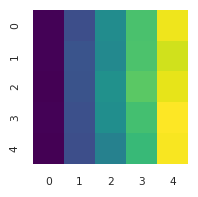

Epoch [9/20], Loss: 0.0004


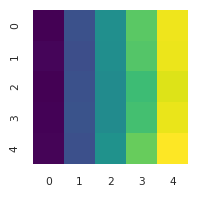

Epoch [10/20], Loss: 0.0003


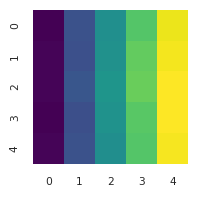

Epoch [11/20], Loss: 0.0003


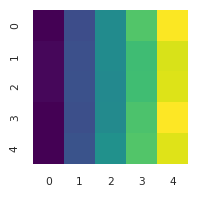

Epoch [12/20], Loss: 0.0002


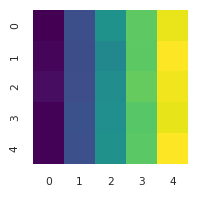

Epoch [13/20], Loss: 0.0002


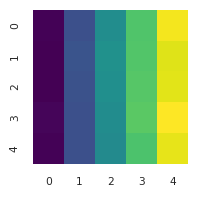

Epoch [14/20], Loss: 0.0002


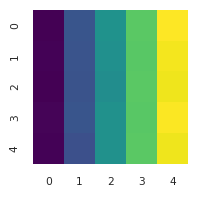

Epoch [15/20], Loss: 0.0002


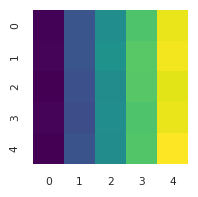

Epoch [16/20], Loss: 0.0002


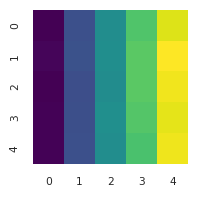

Epoch [17/20], Loss: 0.0001


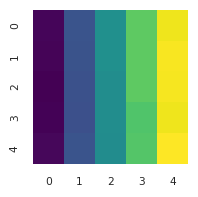

Epoch [18/20], Loss: 0.0001


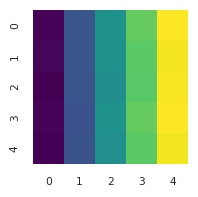

Epoch [19/20], Loss: 0.0001


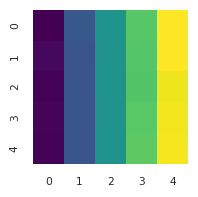

Epoch [20/20], Loss: 0.0001


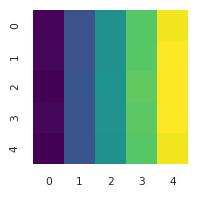

Epoch [1/20], Loss: 0.1719


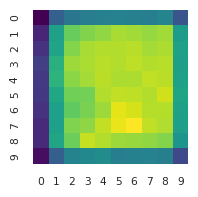

Epoch [2/20], Loss: 0.0682


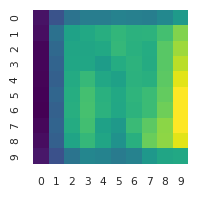

Epoch [3/20], Loss: 0.0311


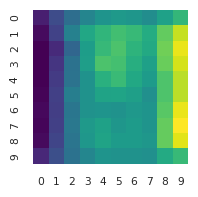

Epoch [4/20], Loss: 0.0153


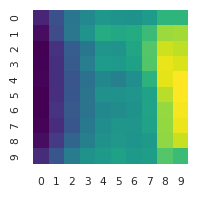

Epoch [5/20], Loss: 0.0087


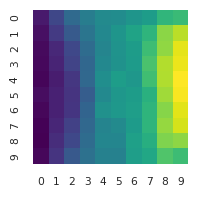

Epoch [6/20], Loss: 0.0050


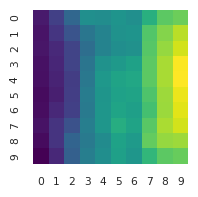

Epoch [7/20], Loss: 0.0031


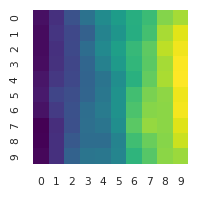

Epoch [8/20], Loss: 0.0021


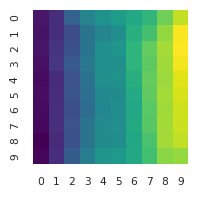

Epoch [9/20], Loss: 0.0016


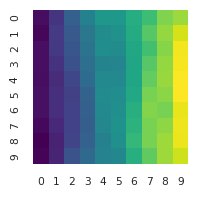

Epoch [10/20], Loss: 0.0013


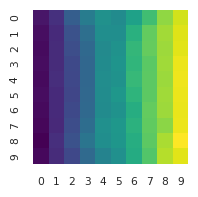

Epoch [11/20], Loss: 0.0011


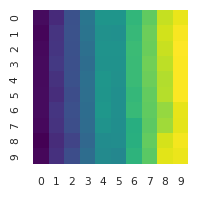

Epoch [12/20], Loss: 0.0010


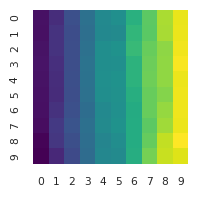

Epoch [13/20], Loss: 0.0009


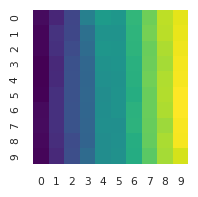

Epoch [14/20], Loss: 0.0008


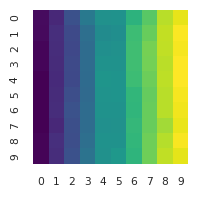

Epoch [15/20], Loss: 0.0008


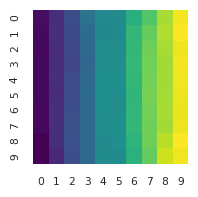

Epoch [16/20], Loss: 0.0007


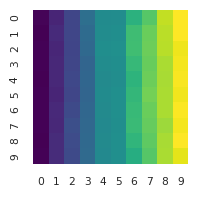

Epoch [17/20], Loss: 0.0007


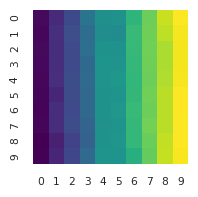

Epoch [18/20], Loss: 0.0007


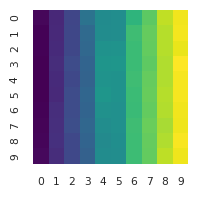

Epoch [19/20], Loss: 0.0007


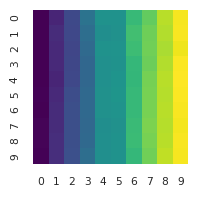

Epoch [20/20], Loss: 0.0006


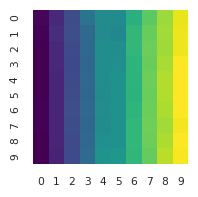

Epoch [1/20], Loss: 0.1367


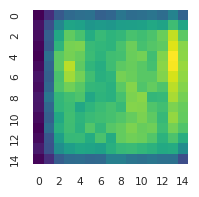

Epoch [2/20], Loss: 0.0415


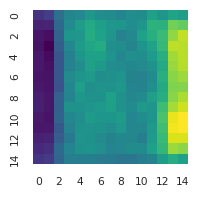

Epoch [3/20], Loss: 0.0201


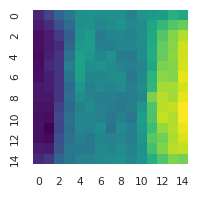

Epoch [4/20], Loss: 0.0150


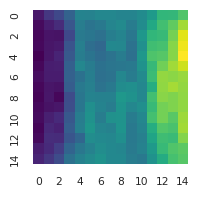

Epoch [5/20], Loss: 0.0127


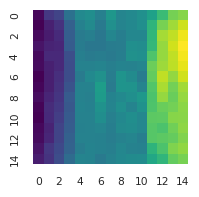

Epoch [6/20], Loss: 0.0114


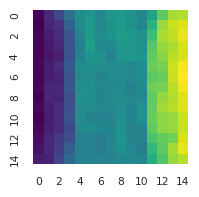

Epoch [7/20], Loss: 0.0107


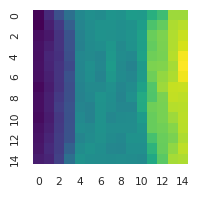

Epoch [8/20], Loss: 0.0103


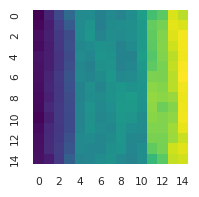

Epoch [9/20], Loss: 0.0101


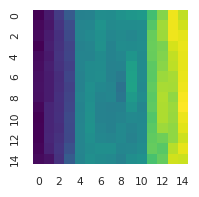

Epoch [10/20], Loss: 0.0099


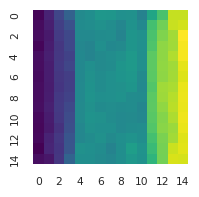

Epoch [11/20], Loss: 0.0098


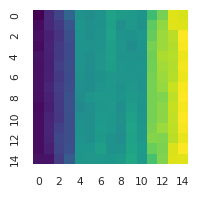

Epoch [12/20], Loss: 0.0098


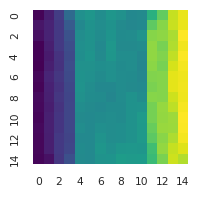

Epoch [13/20], Loss: 0.0097


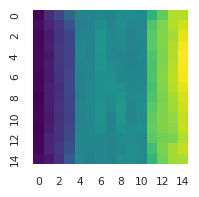

Epoch [14/20], Loss: 0.0096


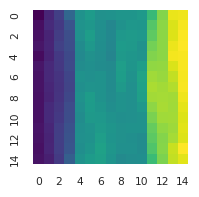

Epoch [15/20], Loss: 0.0096


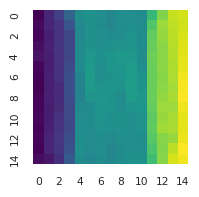

Epoch [16/20], Loss: 0.0096


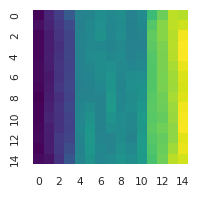

Epoch [17/20], Loss: 0.0095


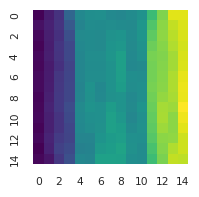

Epoch [18/20], Loss: 0.0095


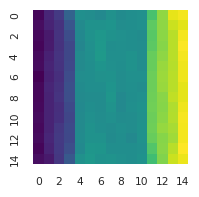

Epoch [19/20], Loss: 0.0095


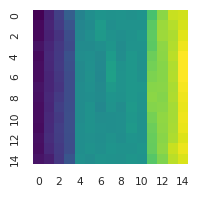

Epoch [20/20], Loss: 0.0095


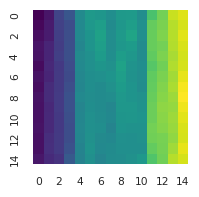

Epoch [1/20], Loss: 0.1548


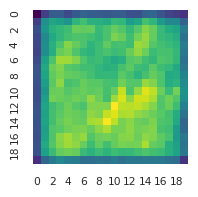

Epoch [2/20], Loss: 0.0798


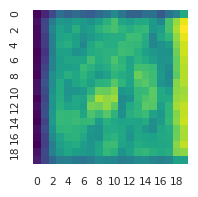

Epoch [3/20], Loss: 0.0436


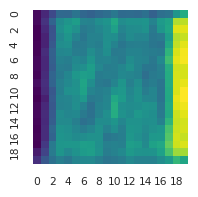

Epoch [4/20], Loss: 0.0357


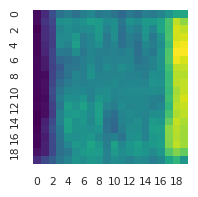

Epoch [5/20], Loss: 0.0315


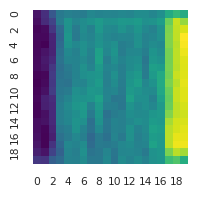

Epoch [6/20], Loss: 0.0288


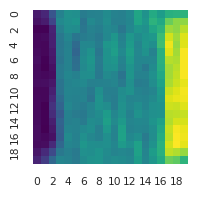

Epoch [7/20], Loss: 0.0270


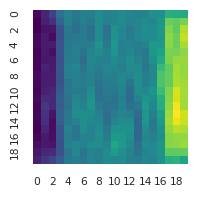

Epoch [8/20], Loss: 0.0253


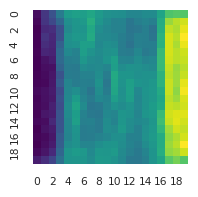

Epoch [9/20], Loss: 0.0235


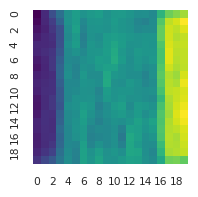

Epoch [10/20], Loss: 0.0218


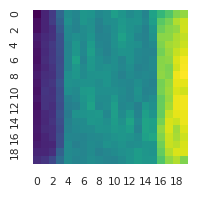

Epoch [11/20], Loss: 0.0207


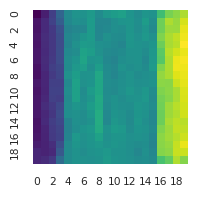

Epoch [12/20], Loss: 0.0203


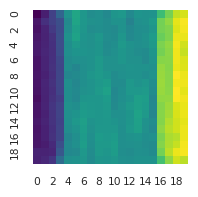

Epoch [13/20], Loss: 0.0200


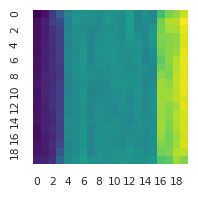

Epoch [14/20], Loss: 0.0199


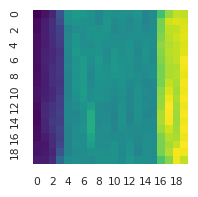

Epoch [15/20], Loss: 0.0197


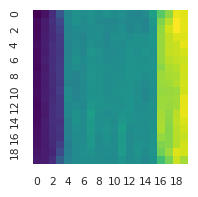

Epoch [16/20], Loss: 0.0194


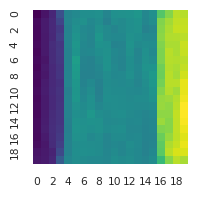

Epoch [17/20], Loss: 0.0192


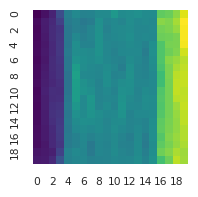

Epoch [18/20], Loss: 0.0188


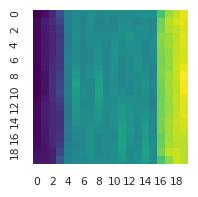

Epoch [19/20], Loss: 0.0185


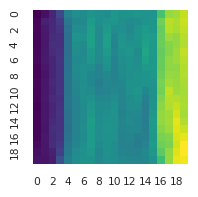

Epoch [20/20], Loss: 0.0184


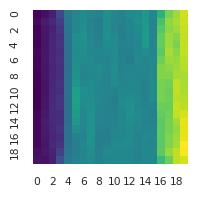

Epoch [1/20], Loss: 0.2122


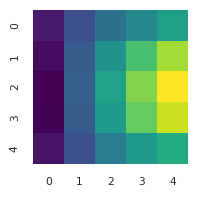

Epoch [2/20], Loss: 0.0152


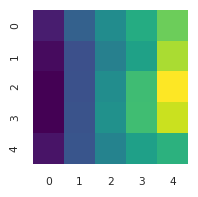

Epoch [3/20], Loss: 0.0037


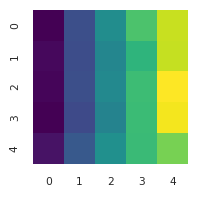

Epoch [4/20], Loss: 0.0010


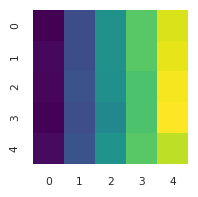

Epoch [5/20], Loss: 0.0002


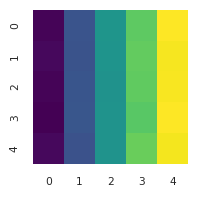

Epoch [6/20], Loss: 0.0001


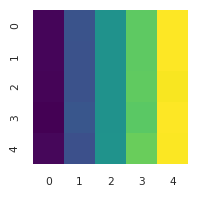

Epoch [7/20], Loss: 0.0000


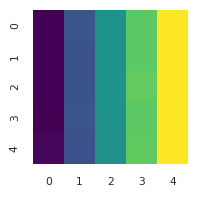

Epoch [8/20], Loss: 0.0000


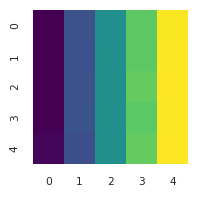

Epoch [9/20], Loss: 0.0000


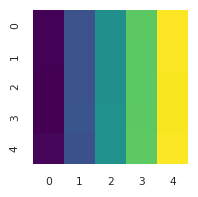

Epoch [10/20], Loss: 0.0000


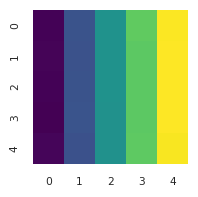

Epoch [11/20], Loss: 0.0000


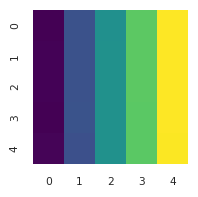

Epoch [12/20], Loss: 0.0000


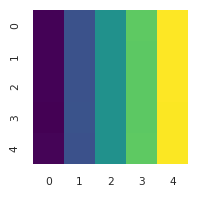

Epoch [13/20], Loss: 0.0000


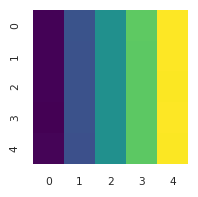

Epoch [14/20], Loss: 0.0000


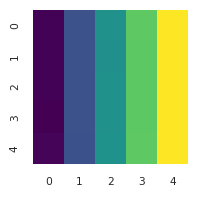

Epoch [15/20], Loss: 0.0000


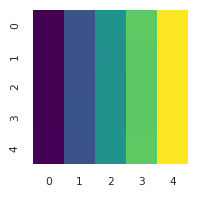

Epoch [16/20], Loss: 0.0000


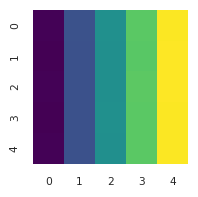

Epoch [17/20], Loss: 0.0000


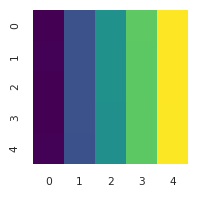

Epoch [18/20], Loss: 0.0000


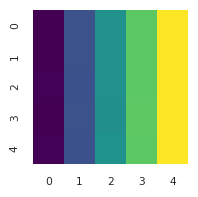

Epoch [19/20], Loss: 0.0000


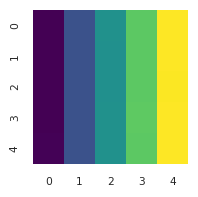

Epoch [20/20], Loss: 0.0000


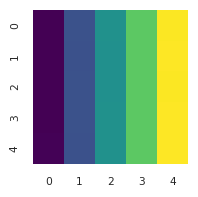

Epoch [1/20], Loss: 0.1493


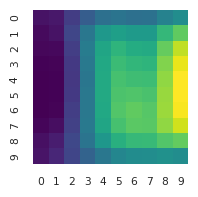

Epoch [2/20], Loss: 0.0132


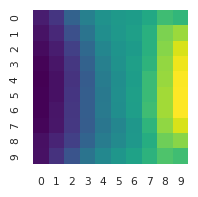

Epoch [3/20], Loss: 0.0048


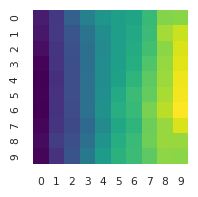

Epoch [4/20], Loss: 0.0018


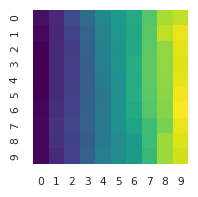

Epoch [5/20], Loss: 0.0010


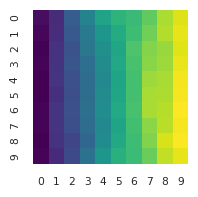

Epoch [6/20], Loss: 0.0007


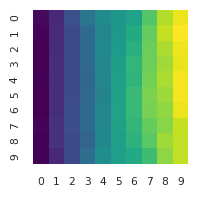

Epoch [7/20], Loss: 0.0006


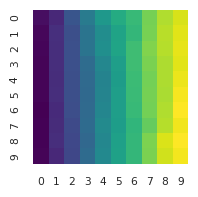

Epoch [8/20], Loss: 0.0005


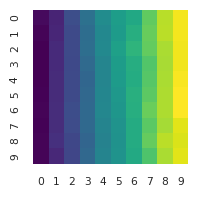

Epoch [9/20], Loss: 0.0004


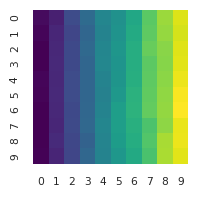

Epoch [10/20], Loss: 0.0003


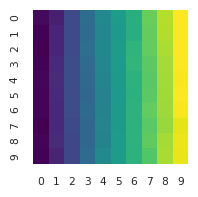

Epoch [11/20], Loss: 0.0003


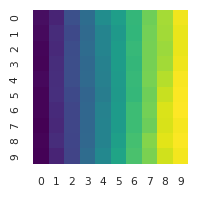

Epoch [12/20], Loss: 0.0003


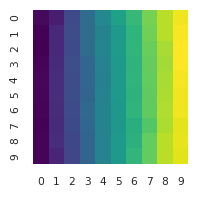

Epoch [13/20], Loss: 0.0002


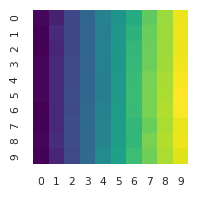

Epoch [14/20], Loss: 0.0002


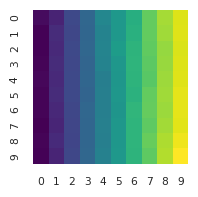

Epoch [15/20], Loss: 0.0002


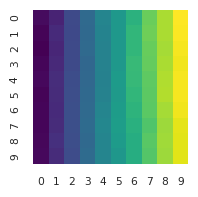

Epoch [16/20], Loss: 0.0002


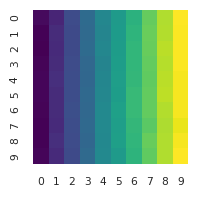

Epoch [17/20], Loss: 0.0002


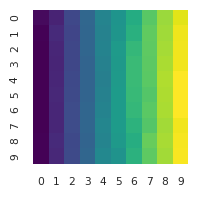

Epoch [18/20], Loss: 0.0001


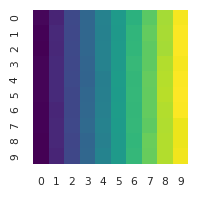

Epoch [19/20], Loss: 0.0001


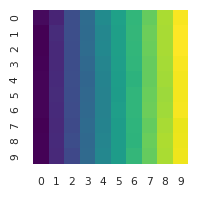

Epoch [20/20], Loss: 0.0001


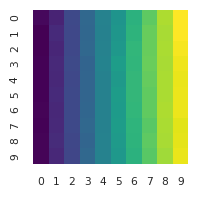

Epoch [1/20], Loss: 0.1323


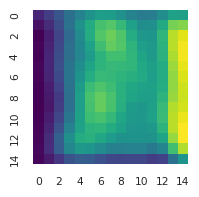

Epoch [2/20], Loss: 0.0264


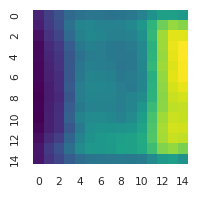

Epoch [3/20], Loss: 0.0091


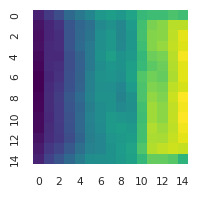

Epoch [4/20], Loss: 0.0043


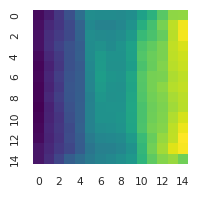

Epoch [5/20], Loss: 0.0027


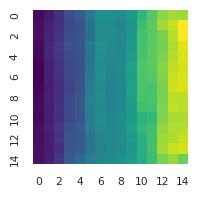

Epoch [6/20], Loss: 0.0021


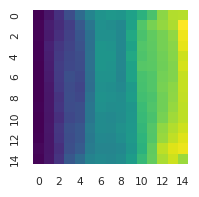

Epoch [7/20], Loss: 0.0018


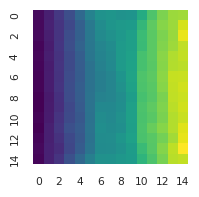

Epoch [8/20], Loss: 0.0016


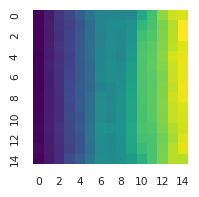

Epoch [9/20], Loss: 0.0014


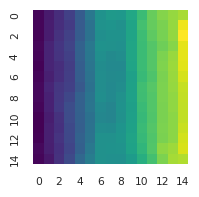

Epoch [10/20], Loss: 0.0012


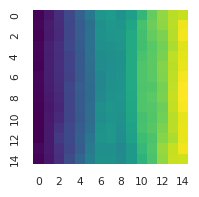

Epoch [11/20], Loss: 0.0011


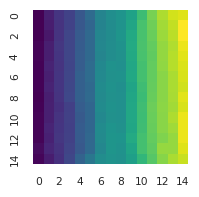

Epoch [12/20], Loss: 0.0010


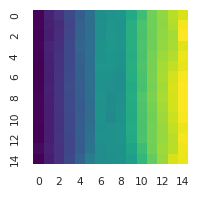

Epoch [13/20], Loss: 0.0009


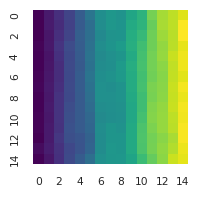

Epoch [14/20], Loss: 0.0009


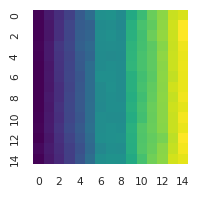

Epoch [15/20], Loss: 0.0008


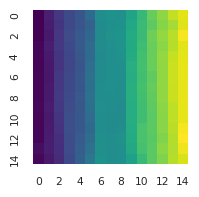

Epoch [16/20], Loss: 0.0008


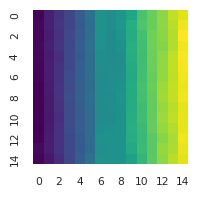

Epoch [17/20], Loss: 0.0008


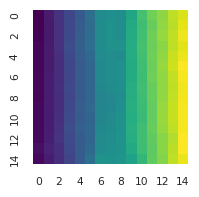

Epoch [18/20], Loss: 0.0008


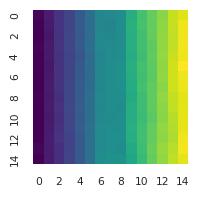

Epoch [19/20], Loss: 0.0008


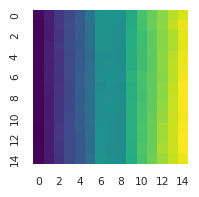

Epoch [20/20], Loss: 0.0008


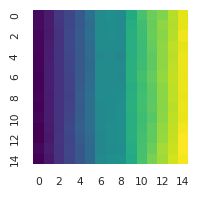

Epoch [1/20], Loss: 0.1436


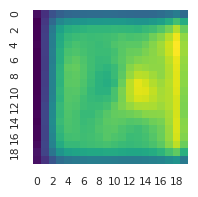

Epoch [2/20], Loss: 0.0335


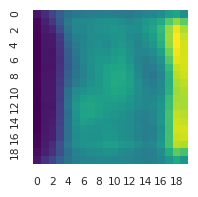

Epoch [3/20], Loss: 0.0173


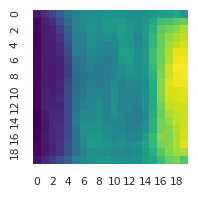

Epoch [4/20], Loss: 0.0116


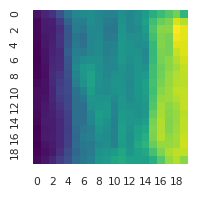

Epoch [5/20], Loss: 0.0098


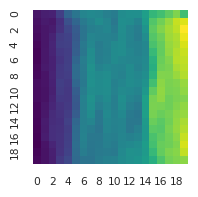

Epoch [6/20], Loss: 0.0088


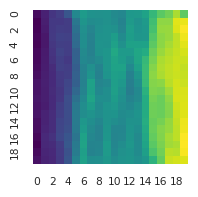

Epoch [7/20], Loss: 0.0081


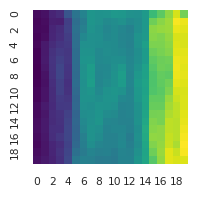

Epoch [8/20], Loss: 0.0077


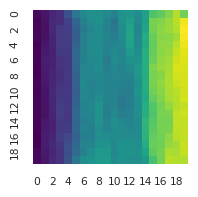

Epoch [9/20], Loss: 0.0073


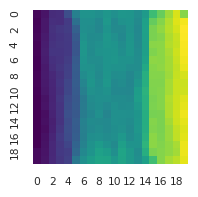

Epoch [10/20], Loss: 0.0070


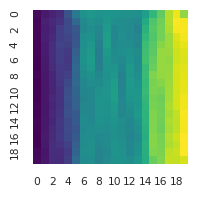

Epoch [11/20], Loss: 0.0067


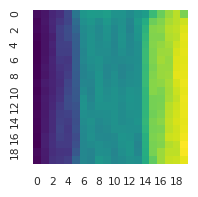

Epoch [12/20], Loss: 0.0066


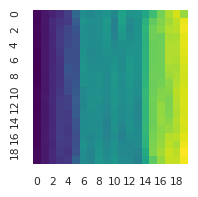

Epoch [13/20], Loss: 0.0064


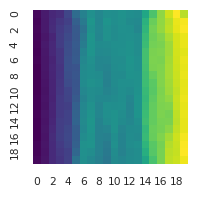

Epoch [14/20], Loss: 0.0063


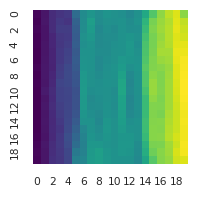

Epoch [15/20], Loss: 0.0062


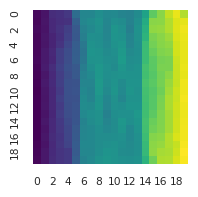

Epoch [16/20], Loss: 0.0060


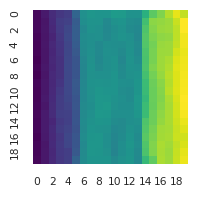

Epoch [17/20], Loss: 0.0059


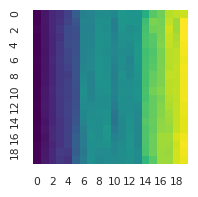

Epoch [18/20], Loss: 0.0058


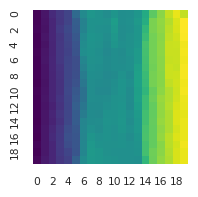

Epoch [19/20], Loss: 0.0055


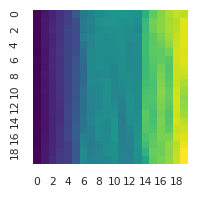

Epoch [20/20], Loss: 0.0052


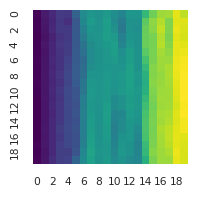

Epoch [1/20], Loss: 0.0957


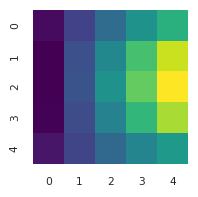

Epoch [2/20], Loss: 0.0079


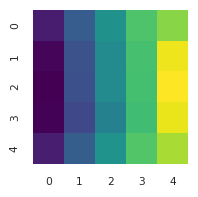

Epoch [3/20], Loss: 0.0005


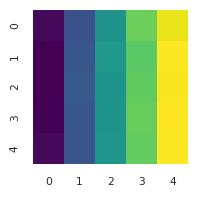

Epoch [4/20], Loss: 0.0001


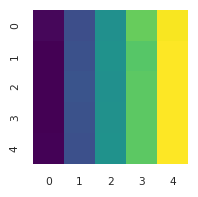

Epoch [5/20], Loss: 0.0000


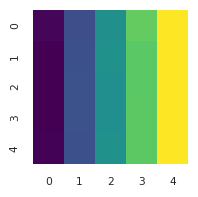

Epoch [6/20], Loss: 0.0000


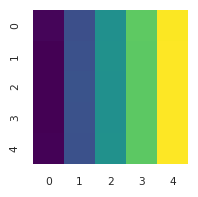

Epoch [7/20], Loss: 0.0000


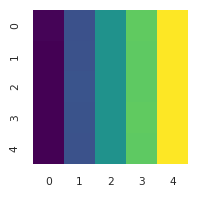

Epoch [8/20], Loss: 0.0000


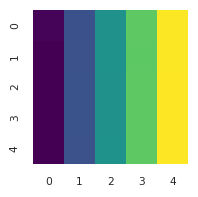

Epoch [9/20], Loss: 0.0000


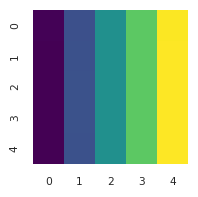

Epoch [10/20], Loss: 0.0000


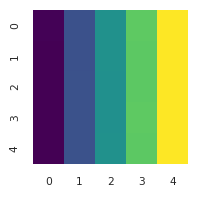

Epoch [11/20], Loss: 0.0000


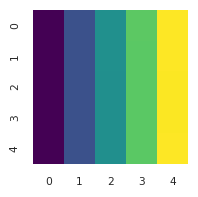

Epoch [12/20], Loss: 0.0000


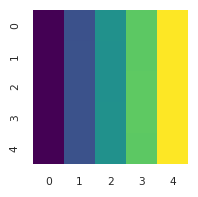

Epoch [13/20], Loss: 0.0000


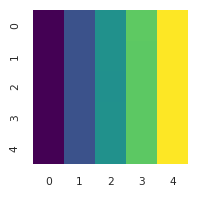

Epoch [14/20], Loss: 0.0000


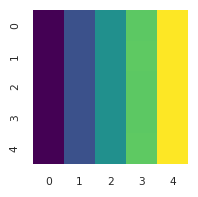

Epoch [15/20], Loss: 0.0000


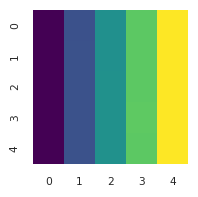

Epoch [16/20], Loss: 0.0000


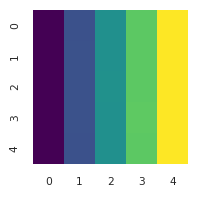

Epoch [17/20], Loss: 0.0000


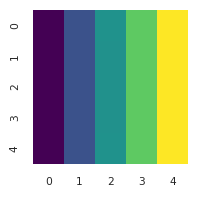

Epoch [18/20], Loss: 0.0000


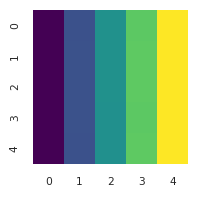

Epoch [19/20], Loss: 0.0000


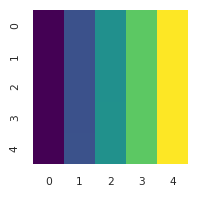

Epoch [20/20], Loss: 0.0000


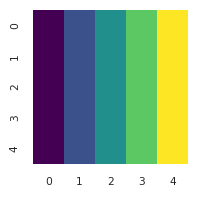

Epoch [1/20], Loss: 0.1700


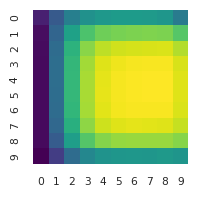

Epoch [2/20], Loss: 0.0163


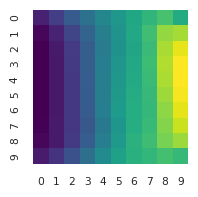

Epoch [3/20], Loss: 0.0024


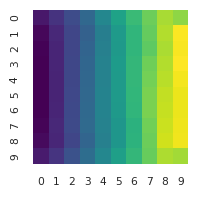

Epoch [4/20], Loss: 0.0004


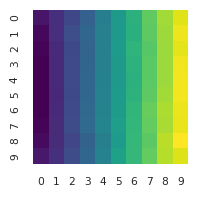

Epoch [5/20], Loss: 0.0002


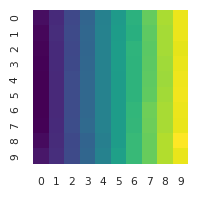

Epoch [6/20], Loss: 0.0001


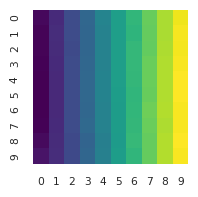

Epoch [7/20], Loss: 0.0001


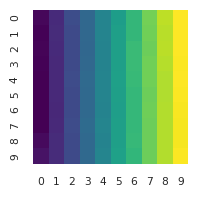

Epoch [8/20], Loss: 0.0001


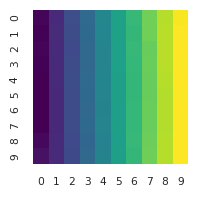

Epoch [9/20], Loss: 0.0001


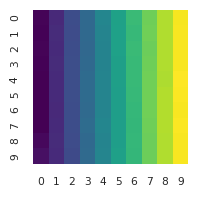

Epoch [10/20], Loss: 0.0000


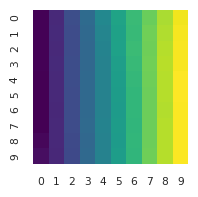

Epoch [11/20], Loss: 0.0000


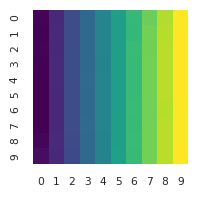

Epoch [12/20], Loss: 0.0000


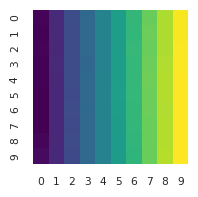

Epoch [13/20], Loss: 0.0000


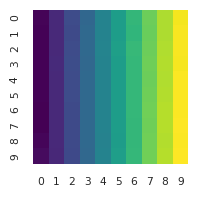

Epoch [14/20], Loss: 0.0000


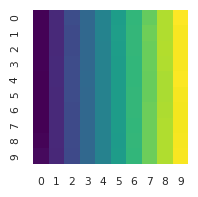

Epoch [15/20], Loss: 0.0000


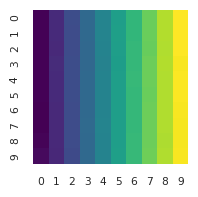

Epoch [16/20], Loss: 0.0000


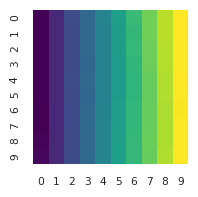

Epoch [17/20], Loss: 0.0000


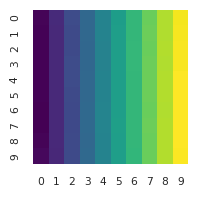

Epoch [18/20], Loss: 0.0000


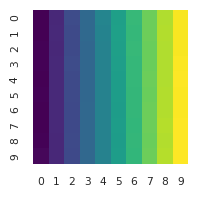

Epoch [19/20], Loss: 0.0000


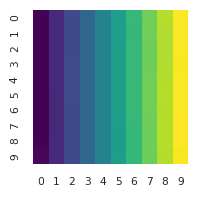

Epoch [20/20], Loss: 0.0000


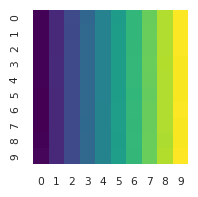

Epoch [1/20], Loss: 0.1388


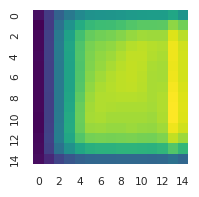

Epoch [2/20], Loss: 0.0191


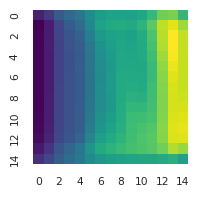

Epoch [3/20], Loss: 0.0035


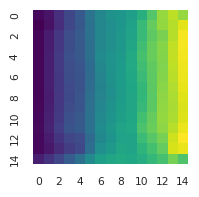

Epoch [4/20], Loss: 0.0014


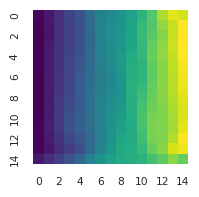

Epoch [5/20], Loss: 0.0009


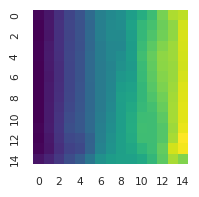

Epoch [6/20], Loss: 0.0006


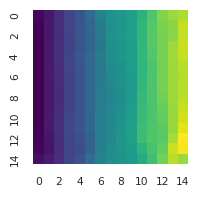

Epoch [7/20], Loss: 0.0005


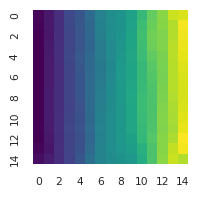

Epoch [8/20], Loss: 0.0004


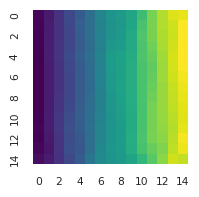

Epoch [9/20], Loss: 0.0003


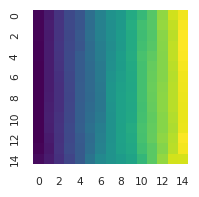

Epoch [10/20], Loss: 0.0002


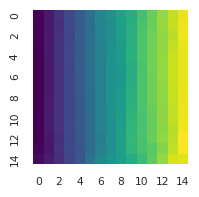

Epoch [11/20], Loss: 0.0002


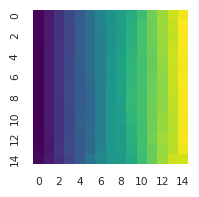

Epoch [12/20], Loss: 0.0002


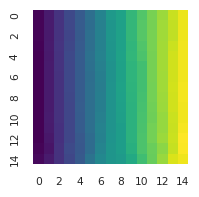

Epoch [13/20], Loss: 0.0002


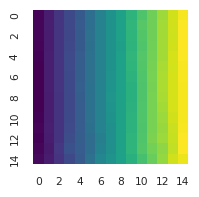

Epoch [14/20], Loss: 0.0001


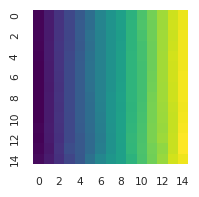

Epoch [15/20], Loss: 0.0001


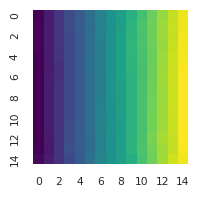

Epoch [16/20], Loss: 0.0001


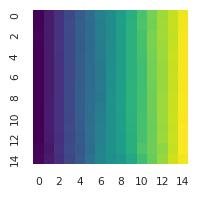

Epoch [17/20], Loss: 0.0001


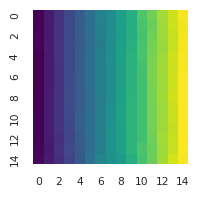

Epoch [18/20], Loss: 0.0001


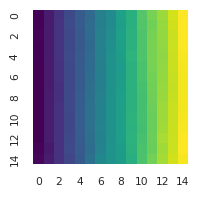

Epoch [19/20], Loss: 0.0001


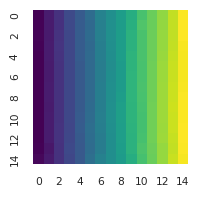

Epoch [20/20], Loss: 0.0001


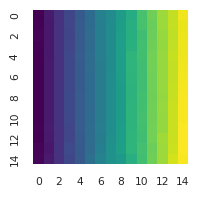

Epoch [1/20], Loss: 0.1377


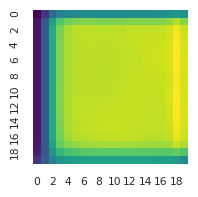

Epoch [2/20], Loss: 0.0346


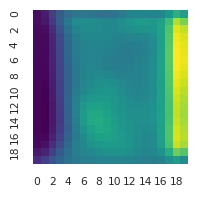

Epoch [3/20], Loss: 0.0123


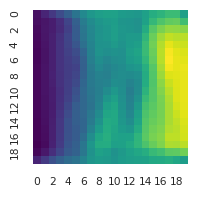

Epoch [4/20], Loss: 0.0044


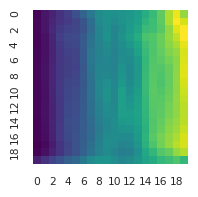

Epoch [5/20], Loss: 0.0023


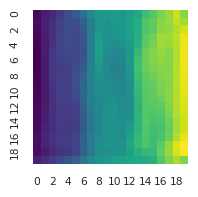

Epoch [6/20], Loss: 0.0017


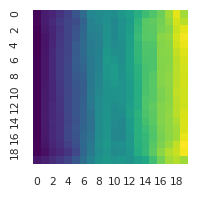

Epoch [7/20], Loss: 0.0014


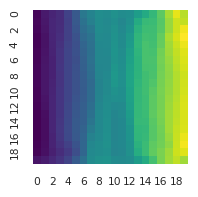

Epoch [8/20], Loss: 0.0012


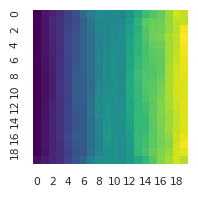

Epoch [9/20], Loss: 0.0010


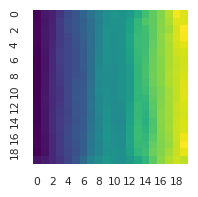

Epoch [10/20], Loss: 0.0009


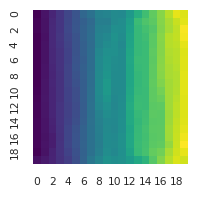

Epoch [11/20], Loss: 0.0008


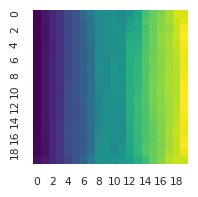

Epoch [12/20], Loss: 0.0007


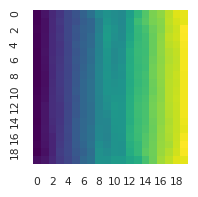

Epoch [13/20], Loss: 0.0006


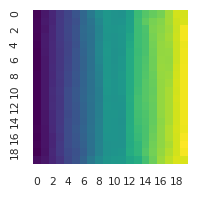

Epoch [14/20], Loss: 0.0007


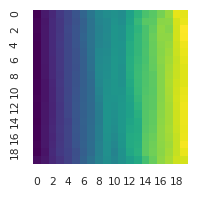

Epoch [15/20], Loss: 0.0005


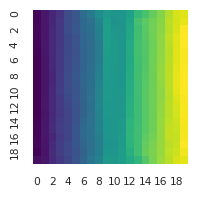

Epoch [16/20], Loss: 0.0005


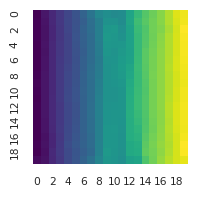

Epoch [17/20], Loss: 0.0004


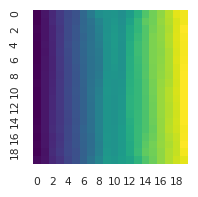

Epoch [18/20], Loss: 0.0004


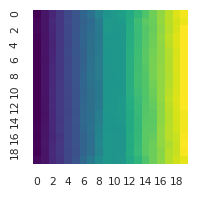

Epoch [19/20], Loss: 0.0004


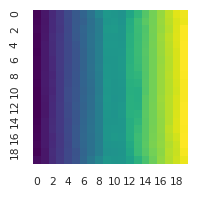

Epoch [20/20], Loss: 0.0004


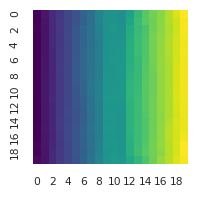

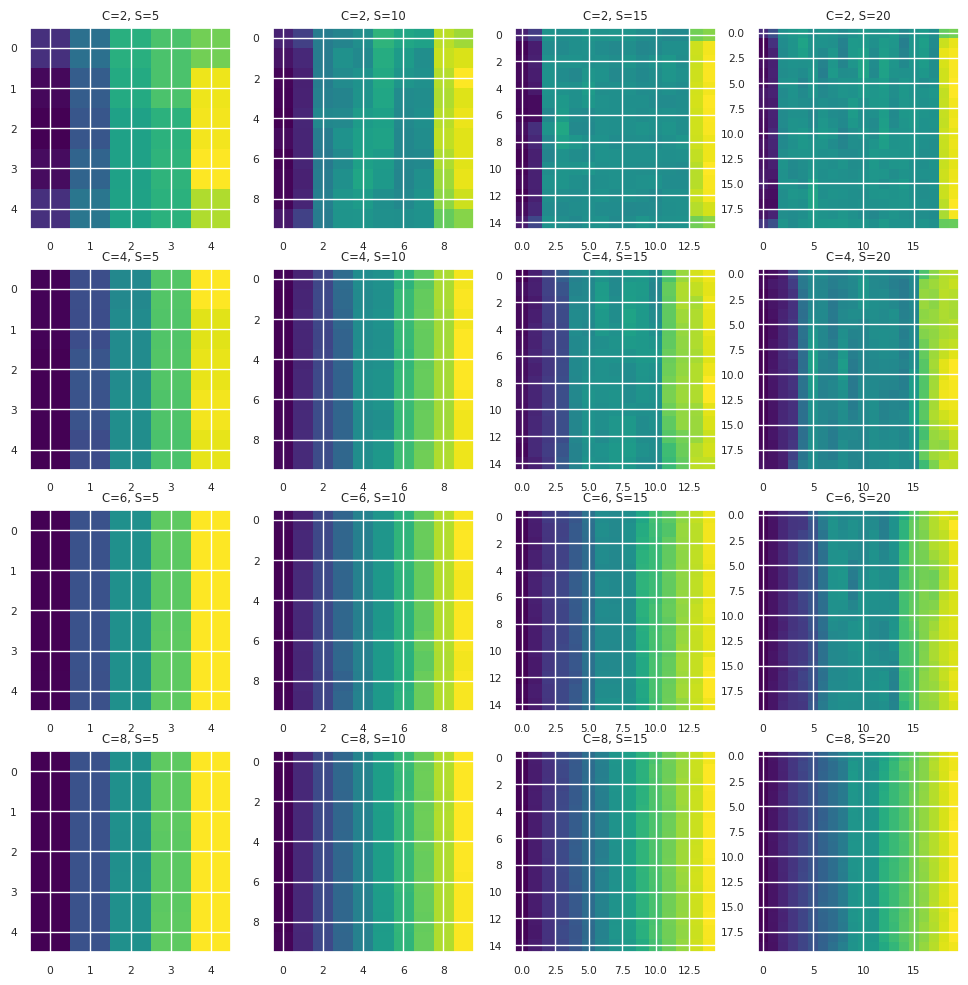

In [33]:
#TODO
n_convolutions_params = [2,4,6,8]
spatial_dimension_params = [5,10,15,20]



results = {}

for n_convolutions in n_convolutions_params:
  for spatial_dimension in spatial_dimension_params:

    model = SimpleConvnet(n_convolutions)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train(epochs=epochs, steps=steps, batch_size=256, model=model, optimizer=optimizer, spatial_dimension=spatial_dimension, verbose=1)

    with torch.no_grad():
        input = generate_noise(1, spatial_dimension)
        predicted_gradient = model(input)[0].numpy()
        #visualize(predicted_gradient.squeeze(0))

        results[(n_convolutions, spatial_dimension)] = predicted_gradient.squeeze(0)

fig, axes = plt.subplots(4,4, figsize=(12,12))

for i, n_convolutions in enumerate(n_convolutions_params):
  for j, spatial_dimension in enumerate(spatial_dimension_params):
    ax = axes[i,j]
    image = results[(n_convolutions, spatial_dimension)]
    im = ax.imshow(image, cmap='viridis')
    ax.set_title(f"C={n_convolutions}, S={spatial_dimension}")
plt.show()
# END TODO